# Forecasting Baselines: Short-Term Point Forecasts for Estimated WEC Power

This notebook builds simple short-term point-forecasting baselines for the estimated WEC power output prepared in the previous notebooks.

The input data used here is the 30-minute Leixões estimated WEC power time series. The sourcing and sea-state preparation are documented in [wave data preparation](01_wave_data_preparation.ipynb), and the simplified WEC power estimation procedure is documented in [WEC power estimation](02_wec_power_estimation.ipynb).

The main modelling target is `wec_power_norm_estimated`, which represents the estimated WEC power normalized by the nominal 250 kW rating used for the generic WEC proxy. This device-relative scale is useful for modelling because it keeps the target independent of larger rated-power or array-sizing assumptions.

For physical interpretation and downstream analysis, the normalized target is also converted to the corresponding 250 kW scale:

`wec_power_kw_estimated = wec_power_norm_estimated × 250 kW`

The main forecasting results in this notebook are reported and visualized on the normalized power scale. The 250 kW-scale true values, predictions, and errors are saved in the prediction output table for later interpretation in the uncertainty and storage-aware analysis notebooks.

The forecast target is not measured WEC power. It is also not a validated device model, hydrodynamic simulation, or wave-to-wire model. It is a simplified, transparent WEC power proxy derived from observed sea-state variables using the assumptions documented in the WEC power estimation notebook.

The purpose of this notebook is to create reproducible point-forecast baselines and residuals that can support the uncertainty and storage-aware subsequent analyses.

The benchmark uses a compact power-only autoregressive feature set. Wave-height, wave-period, and wave-power-flux variables are not used as predictors in the main benchmark, because the estimated WEC power target was itself constructed from sea-state assumptions. This avoids a forecast model that partly relearns the constructed power-matrix mapping instead of forecasting the estimated power series as a time-dependent signal.

The feature set is intentionally kept small: selected lag values, rolling means, and rolling standard deviations of the estimated power series. This keeps the benchmark interpretable and avoids turning the first forecasting notebook into a broad feature-search exercise.

The forecasting horizons are:

| Horizon | Steps | Operational context |
|---:|---:|---|
| 30 min | 1 | Grid-relevant: next balancing or dispatch interval |
| 1 h | 2 | Grid/storage-relevant: near-term operational planning |
| 2 h | 4 | Storage-relevant: short storage dispatch window |
| 4 h | 8 | Grid/storage-relevant: upper short-term benchmark without external wave forecast inputs |

Missing target values are not imputed. Lag, rolling, and future target values are created only within continuous valid segments of the original 30-minute time axis. This prevents observations separated by data gaps from being treated as adjacent 30-minute observations.

Evaluation uses chronological rolling-origin folds. Each fold contains a training block, a calibration/validation block, and a final test block. Using several rolling-origin test folds gives multiple performance estimates across different time periods, which helps assess the stability of the forecasting baselines rather than relying on a single final split.

The notebook compares a small set of interpretable baseline models:

- Persistence
- Rolling mean
- Ridge regression
- Random forest regression

Performance is reported using MAE, RMSE, and skill scores relative to persistence.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True


# Paths
data_path = Path("../data/processed/leixoes_wec_power_30min_estimated.parquet")

output_dir = Path("../outputs/notebook_03")
metrics_path = output_dir / "forecast_metrics.csv"
predictions_path = output_dir / "forecast_predictions.parquet"
folds_path = output_dir / "forecast_folds.csv"


# Target and physical interpretation scale
time_col = "time"
target_col = "wec_power_norm_estimated"
rated_power_kw = 250.0


# Forecast horizons for 30-minute data
horizons = {
    1: {
        "horizon_label": "30 min",
        "horizon_hours": 0.5,
        "operational_context": "Grid-relevant: next balancing or dispatch interval",
    },
    2: {
        "horizon_label": "1 h",
        "horizon_hours": 1.0,
        "operational_context": "Grid/storage-relevant: near-term operational planning",
    },
    4: {
        "horizon_label": "2 h",
        "horizon_hours": 2.0,
        "operational_context": "Storage-relevant: short storage dispatch window",
    },
    8: {
        "horizon_label": "4 h",
        "horizon_hours": 4.0,
        "operational_context": "Grid/storage-relevant: upper short-term benchmark without external wave forecast inputs",
    },
}


# Power-only autoregressive features
lag_steps = [1, 2, 4, 8, 24]
roll_mean_windows = [3, 6, 12]
roll_std_windows = [6, 12]

feature_cols = (
    [f"power_lag_{step}" for step in lag_steps]
    + [f"power_roll_mean_{window}" for window in roll_mean_windows]
    + [f"power_roll_std_{window}" for window in roll_std_windows]
)


# Reproducibility
random_state = 42

## Target availability and continuous segments

Before creating forecasting features, the estimated power target is checked on the original 30-minute time axis.

Missing target values are kept as gaps. Continuous valid segments are identified so that lag, rolling, and future-target features can later be created only within uninterrupted parts of the series.

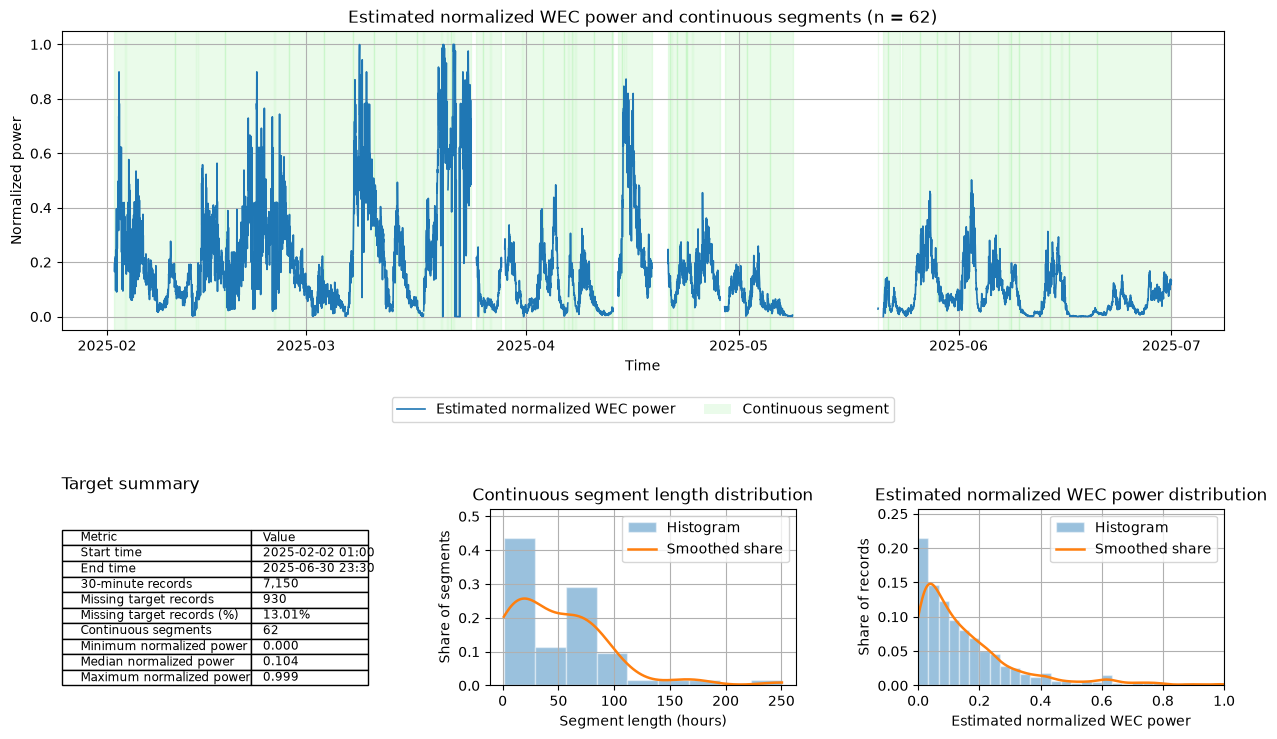

Saved target availability figure to: ../outputs/figures/notebook_03/target_availability_and_segments.png


In [18]:
from scipy.stats import gaussian_kde
from matplotlib.patches import Patch

output_dir.mkdir(parents=True, exist_ok=True)
figures_dir = Path("../outputs/figures/notebook_03")
figures_dir.mkdir(parents=True, exist_ok=True)

target_overview_figure_path = figures_dir / "target_availability_and_segments.png"

df = pd.read_parquet(data_path).copy()

df[time_col] = pd.to_datetime(df[time_col])
df = df.sort_values(time_col).reset_index(drop=True)

required_cols = [
    time_col,
    "hm0_m",
    "tp_s",
    "te_approx_s",
    "wave_power_flux_kw_m_estimated",
    "wec_power_kw_estimated",
    "wec_power_norm_estimated",
    "high_wave_flag",
    "matrix_input_missing_flag",
    "generic_wec_model_id",
]

missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing expected columns: {missing_cols}")


# Identify continuous non-missing target segments on the original 30-minute axis
df["target_available"] = df[target_col].notna()

time_step = pd.Timedelta(minutes=30)
time_gap = df[time_col].diff().ne(time_step)
availability_change = df["target_available"].ne(df["target_available"].shift())

df["continuous_segment_id"] = (time_gap | availability_change).cumsum()
df.loc[~df["target_available"], "continuous_segment_id"] = pd.NA

segment_summary = (
    df.loc[df["target_available"]]
    .groupby("continuous_segment_id", dropna=True)
    .agg(
        start_time=(time_col, "min"),
        end_time=(time_col, "max"),
        n_records=(target_col, "size"),
    )
    .reset_index()
)

segment_summary["duration_hours"] = segment_summary["n_records"] * 0.5


# Compact summary table
missing_count = df[target_col].isna().sum()
missing_pct = missing_count / len(df) * 100

summary_table = pd.DataFrame(
    {
        "Metric": [
            "Start time",
            "End time",
            "30-minute records",
            "Missing target records",
            "Missing target records (%)",
            "Continuous segments",
            "Minimum normalized power",
            "Median normalized power",
            "Maximum normalized power",
        ],
        "Value": [
            df[time_col].min().strftime("%Y-%m-%d %H:%M"),
            df[time_col].max().strftime("%Y-%m-%d %H:%M"),
            f"{len(df):,}",
            f"{missing_count:,}",
            f"{missing_pct:.2f}%",
            f"{len(segment_summary):,}",
            f"{df[target_col].min():.3f}",
            f"{df[target_col].median():.3f}",
            f"{df[target_col].max():.3f}",
        ],
    }
)


# Target overview, segment lengths, and target distribution
fig = plt.figure(figsize=(15, 8.5))
gs = fig.add_gridspec(2, 3, height_ratios=[2.2, 1.3], hspace=0.75, wspace=0.4)

ax_ts = fig.add_subplot(gs[0, :])
ax_table = fig.add_subplot(gs[1, 0])
ax_hist_seg = fig.add_subplot(gs[1, 1])
ax_hist_power = fig.add_subplot(gs[1, 2])

for _, row in segment_summary.iterrows():
    ax_ts.axvspan(
        row["start_time"],
        row["end_time"],
        color="lightgreen",
        alpha=0.18,
        zorder=0,
    )

power_line, = ax_ts.plot(
    df[time_col],
    df[target_col],
    linewidth=1.2,
    label="Estimated normalized WEC power",
    zorder=2,
)

segment_patch = Patch(
    facecolor="lightgreen",
    alpha=0.18,
    label="Continuous segment",
)

ax_ts.set_title(
    f"Estimated normalized WEC power and continuous segments (n = {len(segment_summary)})"
)
ax_ts.set_xlabel("Time")
ax_ts.set_ylabel("Normalized power")
ax_ts.legend(
    handles=[power_line, segment_patch],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.20),
    ncol=2,
    frameon=True,
)

ax_table.axis("off")
ax_table.set_title("Target summary", loc="left", pad=14)

table = ax_table.table(
    cellText=summary_table.values,
    colLabels=summary_table.columns,
    cellLoc="left",
    colLoc="left",
    colWidths=[0.62, 0.38],
    bbox=[0, 0, 1, 0.88],
)

table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.15)


# Continuous segment length distribution
segment_lengths = segment_summary["duration_hours"]
segment_bins = np.histogram_bin_edges(segment_lengths, bins="auto")
segment_bin_width = np.diff(segment_bins).mean()
segment_weights = np.ones(len(segment_lengths)) / len(segment_lengths)

seg_hist_values, _, _ = ax_hist_seg.hist(
    segment_lengths,
    bins=segment_bins,
    weights=segment_weights,
    alpha=0.45,
    edgecolor="white",
    label="Histogram",
)

if segment_lengths.nunique() > 1:
    x_grid_seg = np.linspace(segment_lengths.min(), segment_lengths.max(), 300)
    kde_seg = gaussian_kde(segment_lengths)
    kde_seg_share = kde_seg(x_grid_seg) * segment_bin_width

    ax_hist_seg.plot(
        x_grid_seg,
        kde_seg_share,
        linewidth=1.8,
        label="Smoothed share",
    )

    seg_ymax = max(seg_hist_values.max(), kde_seg_share.max()) * 1.2
else:
    seg_ymax = seg_hist_values.max() * 1.2

ax_hist_seg.set_title("Continuous segment length distribution")
ax_hist_seg.set_xlabel("Segment length (hours)")
ax_hist_seg.set_ylabel("Share of segments")
ax_hist_seg.set_ylim(0, min(1, seg_ymax))
ax_hist_seg.legend(frameon=True)


# Estimated normalized WEC power distribution
power_values = df.loc[df[target_col].notna(), target_col]

power_bins = np.linspace(0, 1, 31)
power_bin_width = power_bins[1] - power_bins[0]
power_weights = np.ones(len(power_values)) / len(power_values)

power_hist_values, _, _ = ax_hist_power.hist(
    power_values,
    bins=power_bins,
    weights=power_weights,
    alpha=0.45,
    edgecolor="white",
    label="Histogram",
)

if power_values.nunique() > 1:
    x_grid_power = np.linspace(0, 1, 300)
    kde_power = gaussian_kde(power_values)
    kde_power_share = kde_power(x_grid_power) * power_bin_width

    ax_hist_power.plot(
        x_grid_power,
        kde_power_share,
        linewidth=1.8,
        label="Smoothed share",
    )

    power_ymax = max(power_hist_values.max(), kde_power_share.max()) * 1.2
else:
    power_ymax = power_hist_values.max() * 1.2

ax_hist_power.set_title("Estimated normalized WEC power distribution")
ax_hist_power.set_xlabel("Estimated normalized WEC power")
ax_hist_power.set_ylabel("Share of records")
ax_hist_power.set_xlim(0, 1)
ax_hist_power.set_ylim(0, min(1, power_ymax))
ax_hist_power.legend(frameon=True)

fig.savefig(target_overview_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved target availability figure to: {target_overview_figure_path}")

The target series contains 62 continuous non-missing segments, with about 13% missing target records on the original 30-minute time axis. Estimated normalized WEC power is concentrated at low-to-moderate output levels, with fewer near-rated values.

The following forecasting features are therefore created within each continuous segment only, so lagged and rolling predictors do not cross missing-data gaps.

## Segment-safe forecasting features

Forecasting features are created from the estimated normalized WEC power series only.

For each forecast horizon, the regression target is the future estimated normalized WEC power, `y_target_norm`, evaluated at the corresponding `target_time`.

The same compact autoregressive feature set is used for all horizons:

- `power_lag_1`
- `power_lag_2`
- `power_lag_4`
- `power_lag_8`
- `power_lag_24`
- `power_roll_mean_3`
- `power_roll_mean_6`
- `power_roll_mean_12`
- `power_roll_std_6`
- `power_roll_std_12`

Lag and rolling features are computed within each continuous segment. Rolling features use past values only. Future targets are also created within each segment, so forecast examples do not cross missing-data gaps.

,horizon,horizon_steps,horizon_hours,supervised_rows,share_of_available_target_records
0,30 min,1,0.5,4866,78.23
1,1 h,2,1.0,4819,77.48
2,2 h,4,2.0,4727,76.00
3,4 h,8,4.0,4545,73.07


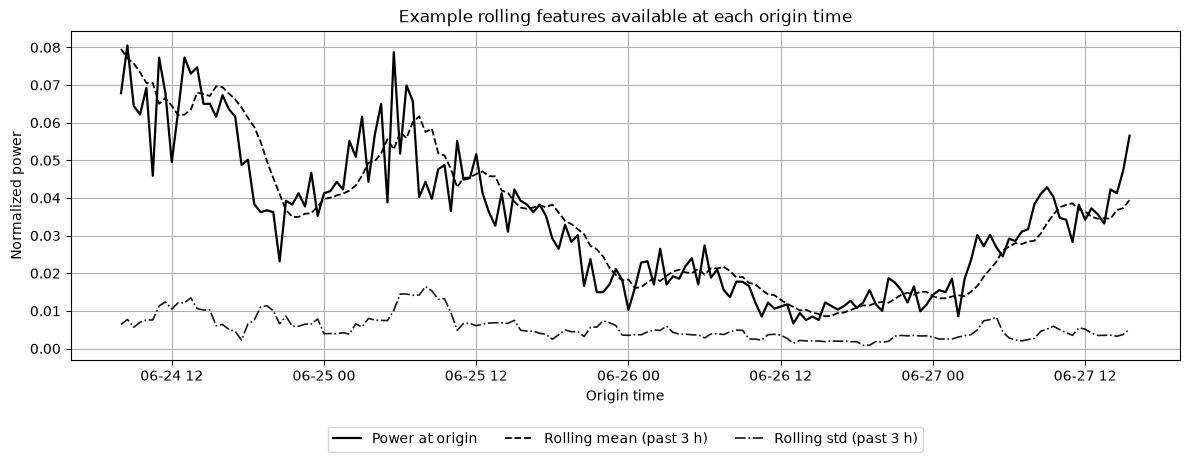

In [3]:
# Create lag and rolling features within each continuous segment
feature_df = df.copy()
grouped_power = feature_df.groupby("continuous_segment_id", dropna=True)[target_col]

for step in lag_steps:
    feature_df[f"power_lag_{step}"] = grouped_power.shift(step)

past_power = grouped_power.shift(1)

for window in roll_mean_windows:
    feature_df[f"power_roll_mean_{window}"] = (
        past_power
        .groupby(feature_df["continuous_segment_id"], dropna=True)
        .rolling(window=window, min_periods=window)
        .mean()
        .reset_index(level=0, drop=True)
    )

for window in roll_std_windows:
    feature_df[f"power_roll_std_{window}"] = (
        past_power
        .groupby(feature_df["continuous_segment_id"], dropna=True)
        .rolling(window=window, min_periods=window)
        .std()
        .reset_index(level=0, drop=True)
    )


# Build one supervised dataset per horizon
supervised_by_horizon = {}

for horizon_steps, info in horizons.items():
    horizon_df = feature_df.copy()

    horizon_df["target_time"] = (
        horizon_df
        .groupby("continuous_segment_id", dropna=True)[time_col]
        .shift(-horizon_steps)
    )

    horizon_df["y_target_norm"] = (
        horizon_df
        .groupby("continuous_segment_id", dropna=True)[target_col]
        .shift(-horizon_steps)
    )

    horizon_df["horizon_steps"] = horizon_steps
    horizon_df["horizon_hours"] = info["horizon_hours"]
    horizon_df["horizon_label"] = info["horizon_label"]

    supervised_cols = (
        [time_col, "target_time", "continuous_segment_id"]
        + feature_cols
        + ["y_target_norm", target_col, "horizon_steps", "horizon_hours", "horizon_label"]
    )

    horizon_df = horizon_df[supervised_cols].dropna(
        subset=feature_cols + ["y_target_norm"]
    )

    horizon_df = horizon_df.rename(columns={time_col: "origin_time"})

    supervised_by_horizon[horizon_steps] = horizon_df.reset_index(drop=True)


# Supervised sample counts by horizon
supervised_summary = pd.DataFrame(
    [
        {
            "horizon": horizons[horizon_steps]["horizon_label"],
            "horizon_steps": horizon_steps,
            "horizon_hours": horizons[horizon_steps]["horizon_hours"],
            "supervised_rows": len(horizon_df),
            "share_of_available_target_records": len(horizon_df) / df["target_available"].sum() * 100,
        }
        for horizon_steps, horizon_df in supervised_by_horizon.items()
    ]
)

supervised_summary["share_of_available_target_records"] = (
    supervised_summary["share_of_available_target_records"].round(2)
)

display(supervised_summary)


# Example rolling-feature window at origin time
# The same feature construction is used for all forecast horizons,
# so one horizon is enough for illustration.
example_horizon_steps = 2
example_horizon_df = supervised_by_horizon[example_horizon_steps]

example_segment_id = (
    example_horizon_df
    .groupby("continuous_segment_id")
    .size()
    .sort_values(ascending=False)
    .index[0]
)

plot_df = example_horizon_df.loc[
    example_horizon_df["continuous_segment_id"] == example_segment_id
].copy()

window_size = min(len(plot_df), 160)
start_idx = max((len(plot_df) - window_size) // 2, 0)
plot_df = plot_df.iloc[start_idx:start_idx + window_size]

fig, ax = plt.subplots(figsize=(12, 4.8))

ax.plot(
    plot_df["origin_time"],
    plot_df[target_col],
    color="black",
    linewidth=1.6,
    label="Power at origin",
)

ax.plot(
    plot_df["origin_time"],
    plot_df["power_roll_mean_6"],
    color="black",
    linestyle="--",
    linewidth=1.3,
    label="Rolling mean (past 3 h)",
)

ax.plot(
    plot_df["origin_time"],
    plot_df["power_roll_std_6"],
    color="black",
    linestyle="-.",
    linewidth=1.2,
    alpha=0.9,
    label="Rolling std (past 3 h)",
)

ax.set_title("Example rolling features available at each origin time")
ax.set_xlabel("Origin time")
ax.set_ylabel("Normalized power")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    frameon=True,
)

plt.tight_layout()
plt.show()

## Rolling-origin folds

The supervised rows are split chronologically into 5 rolling-origin folds.

Each fold uses an expanding chronological prefix of the supervised record. Within each fold, the split is approximately 70% training, 15% calibration/validation, and 15% test. The later folds use longer prefixes, so they include more training and evaluation samples.

The calibration/validation block is kept separate because the same fold structure will later support prediction-interval calibration in the uncertainty analysis.

In [4]:
n_folds = 5

train_fraction = 0.70
calibration_fraction = 0.15
test_fraction = 0.15

folds_dir = Path("../data/processed/folds")
folds_dir.mkdir(parents=True, exist_ok=True)

folds_path = folds_dir / "forecast_folds.parquet"

fold_records = []

for horizon_steps, horizon_df in supervised_by_horizon.items():
    horizon_df = horizon_df.sort_values("origin_time").reset_index(drop=True).copy()
    horizon_df["sample_id"] = np.arange(len(horizon_df))
    supervised_by_horizon[horizon_steps] = horizon_df

    n_rows = len(horizon_df)

    # Use expanding chronological prefixes ending in the later part of the record.
    fold_end_positions = np.linspace(
        int(np.floor(0.80 * n_rows)),
        n_rows,
        n_folds,
        dtype=int,
    )

    if len(np.unique(fold_end_positions)) < n_folds:
        raise ValueError(f"Not enough supervised rows for {n_folds} folds at horizon {horizon_steps}.")

    for fold_id, fold_end in enumerate(fold_end_positions, start=1):
        train_end = int(np.floor(fold_end * train_fraction))
        calibration_end = train_end + int(np.floor(fold_end * calibration_fraction))
        test_end = fold_end

        split_blocks = {
            "train": (0, train_end),
            "calibration": (train_end, calibration_end),
            "test": (calibration_end, test_end),
        }

        for split_name, (start, end) in split_blocks.items():
            split_df = horizon_df.iloc[start:end][
                [
                    "sample_id",
                    "origin_time",
                    "target_time",
                    "horizon_steps",
                    "horizon_hours",
                    "horizon_label",
                ]
            ].copy()

            split_df["fold_id"] = fold_id
            split_df["split"] = split_name

            fold_records.append(split_df)

folds_df = pd.concat(fold_records, ignore_index=True)

folds_df = folds_df[
    [
        "horizon_steps",
        "horizon_hours",
        "horizon_label",
        "fold_id",
        "split",
        "sample_id",
        "origin_time",
        "target_time",
    ]
].sort_values(
    ["horizon_steps", "fold_id", "origin_time"]
).reset_index(drop=True)


# Split counts and percentages within each fold
fold_split_counts = (
    folds_df
    .groupby(["horizon_steps", "horizon_label", "fold_id", "split"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

for split_name in ["train", "calibration", "test"]:
    if split_name not in fold_split_counts.columns:
        fold_split_counts[split_name] = 0

fold_split_counts["total"] = (
    fold_split_counts["train"]
    + fold_split_counts["calibration"]
    + fold_split_counts["test"]
)

fold_split_summary = fold_split_counts[
    ["horizon_steps", "horizon_label", "fold_id"]
].copy()

for split_name in ["train", "calibration", "test"]:
    pct = 100 * fold_split_counts[split_name] / fold_split_counts["total"]
    fold_split_summary[split_name] = (
        fold_split_counts[split_name].astype(int).astype(str)
        + " ("
        + pct.round(1).astype(str)
        + "%)"
    )

fold_split_summary = fold_split_summary[
    ["horizon_steps", "horizon_label", "fold_id", "train", "calibration", "test"]
]

fold_split_summary.columns.name = None

display(
    fold_split_summary.sort_values(
        ["horizon_steps", "fold_id"]
    ).reset_index(drop=True)
)


# Save fold structure for downstream uncertainty analysis
folds_df.to_parquet(folds_path, index=False)

print(f"Saved fold definitions to: {folds_path}")

,horizon_steps,horizon_label,fold_id,train,calibration,test
0,1,30 min,1,2724 (70.0%),583 (15.0%),585 (15.0%)
1,1,30 min,2,2894 (70.0%),620 (15.0%),621 (15.0%)
2,1,30 min,3,3065 (70.0%),656 (15.0%),658 (15.0%)
3,1,30 min,4,3235 (70.0%),693 (15.0%),694 (15.0%)
4,1,30 min,5,3406 (70.0%),729 (15.0%),731 (15.0%)
5,2,1 h,1,2698 (70.0%),578 (15.0%),579 (15.0%)
6,2,1 h,2,2867 (70.0%),614 (15.0%),615 (15.0%)
7,2,1 h,3,3035 (70.0%),650 (15.0%),652 (15.0%)
8,2,1 h,4,3204 (70.0%),686 (15.0%),688 (15.0%)
9,2,1 h,5,3373 (70.0%),722 (15.0%),724 (15.0%)


Saved fold definitions to: ../data/processed/folds/forecast_folds.parquet


## Forecasting models

The benchmark uses four simple point-forecasting models:

- **Persistence** — predicts the future value using the current estimated power at the forecast origin. No hyperparameters.
- **Rolling mean** — predicts the future value using a recent rolling mean of estimated power, with the rolling window selected from $w \in \{3, 6, 12\}$ 30-minute steps.
- **Ridge regression** — regularized linear autoregressive model implemented with scikit-learn, with regularization strength selected from $\alpha \in \{0.1, 1.0, 10.0\}$.
- **Random forest regression** — non-linear tree-based benchmark implemented with scikit-learn, with a small grid over tree depth and leaf size: $d_{\max} \in \{6, 12, \mathrm{None}\}$ and $n_{\mathrm{min\ leaf}} \in \{3, 5, 10\}$.

Ridge regression uses a `StandardScaler` inside a scikit-learn pipeline, fitted only on the training block of each fold. The baseline models and random forest do not require feature scaling.

Hyperparameter selection uses a small manual grid search within each fold: models are fitted on the training block, candidate settings are compared on the calibration/validation block, and final performance is reported on the test block.

In [5]:
from sklearn.model_selection import ParameterGrid

model_grids = {
    "Persistence": [{}],
    "RollingMean": [
        {"feature": f"power_roll_mean_{window}"}
        for window in roll_mean_windows
    ],
    "Ridge": [
        {"alpha": alpha}
        for alpha in [0.1, 1.0, 10.0]
    ],
    "RandomForest": list(
        ParameterGrid(
            {
                "max_depth": [6, 12, None],
                "min_samples_leaf": [3, 5, 10],
            }
        )
    ),
}


def build_model(model_name, params):
    if model_name == "Ridge":
        return make_pipeline(
            StandardScaler(),
            Ridge(alpha=params["alpha"]),
        )

    if model_name == "RandomForest":
        return RandomForestRegressor(
            n_estimators=300,
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            random_state=random_state,
            n_jobs=-1,
        )

    return None

## Fold-wise model fitting and prediction

For each horizon and fold, candidate model settings are fitted on the training block and compared on the calibration/validation block. The selected setting is then used to generate predictions for the calibration and test blocks.

The test block is not used for model fitting or hyperparameter selection.

The saved prediction table keeps the selected point forecasts and residuals for downstream uncertainty analysis. Fitted fold-specific models are also saved so the selected forecasting objects can be inspected or reused later.

In [6]:
import json
import time
import joblib
from tqdm import tqdm


models_dir = Path("../outputs/models/notebook_03")
models_dir.mkdir(parents=True, exist_ok=True)

tables_dir = Path("../outputs/tables/notebook_03")
tables_dir.mkdir(parents=True, exist_ok=True)

predictions_path = output_dir / "forecast_predictions.parquet"

model_selection_path = tables_dir / "model_selection.csv"
model_runtime_path = tables_dir / "model_runtime.csv"
selection_summary_path = tables_dir / "model_selection_summary.csv"
runtime_summary_path = tables_dir / "model_runtime_summary.csv"


def format_params(params):
    if not params:
        return ""

    return ", ".join(
        f"{key}={value}"
        for key, value in params.items()
    )


def predict_baseline(model_name, params, data):
    if model_name == "Persistence":
        return data[target_col].to_numpy()

    if model_name == "RollingMean":
        return data[params["feature"]].to_numpy()

    raise ValueError(f"Unknown baseline model: {model_name}")


def fit_model(model_name, params, train_data):
    if model_name in ["Persistence", "RollingMean"]:
        return None

    model = build_model(model_name, params)
    model.fit(train_data[feature_cols], train_data["y_target_norm"])

    return model


def predict_model(model_name, params, model, pred_data):
    if model_name in ["Persistence", "RollingMean"]:
        return predict_baseline(model_name, params, pred_data)

    return model.predict(pred_data[feature_cols])


prediction_records = []
selection_records = []
runtime_records = []

tasks = [
    (horizon_steps, fold_id, model_name)
    for horizon_steps in supervised_by_horizon.keys()
    for fold_id in sorted(folds_df["fold_id"].unique())
    for model_name in model_grids.keys()
]

progress_bar = tqdm(
    tasks,
    desc="Fitting forecast models",
    dynamic_ncols=True,
    leave=True,
)

for horizon_steps, fold_id, model_name in progress_bar:
    progress_bar.set_postfix(
        {
            "horizon": horizons[horizon_steps]["horizon_label"],
            "fold": fold_id,
            "model": model_name,
        }
    )

    horizon_df = supervised_by_horizon[horizon_steps].sort_values("sample_id").reset_index(drop=True)

    fold_rows = folds_df[
        (folds_df["horizon_steps"] == horizon_steps)
        & (folds_df["fold_id"] == fold_id)
    ]

    train_ids = fold_rows.loc[fold_rows["split"] == "train", "sample_id"].to_numpy()
    calibration_ids = fold_rows.loc[fold_rows["split"] == "calibration", "sample_id"].to_numpy()
    test_ids = fold_rows.loc[fold_rows["split"] == "test", "sample_id"].to_numpy()

    train_data = horizon_df.iloc[train_ids].copy()
    calibration_data = horizon_df.iloc[calibration_ids].copy()
    test_data = horizon_df.iloc[test_ids].copy()

    candidate_scores = []
    tuning_start = time.perf_counter()

    for params in model_grids[model_name]:
        fit_start = time.perf_counter()
        candidate_model = fit_model(model_name, params, train_data)
        candidate_fit_time = time.perf_counter() - fit_start

        predict_start = time.perf_counter()
        y_pred_calibration = predict_model(
            model_name,
            params,
            candidate_model,
            calibration_data,
        )
        candidate_predict_time = time.perf_counter() - predict_start

        y_pred_calibration = np.clip(y_pred_calibration, 0, 1)

        calibration_rmse = np.sqrt(
            mean_squared_error(
                calibration_data["y_target_norm"],
                y_pred_calibration,
            )
        )

        calibration_mae = mean_absolute_error(
            calibration_data["y_target_norm"],
            y_pred_calibration,
        )

        candidate_scores.append(
            {
                "params": params,
                "calibration_rmse": calibration_rmse,
                "calibration_mae": calibration_mae,
                "candidate_fit_time_seconds": candidate_fit_time,
                "candidate_predict_time_seconds": candidate_predict_time,
            }
        )

    tuning_time = time.perf_counter() - tuning_start

    best_candidate = sorted(
        candidate_scores,
        key=lambda x: (x["calibration_rmse"], x["calibration_mae"]),
    )[0]

    best_params = best_candidate["params"]
    params_label = format_params(best_params)

    final_fit_start = time.perf_counter()
    final_model = fit_model(model_name, best_params, train_data)
    final_fit_time = time.perf_counter() - final_fit_start

    model_path = models_dir / (
        f"h{horizon_steps:02d}_fold{fold_id:02d}_{model_name.lower()}.pkl"
    )

    model_object = {
        "model_name": model_name,
        "params": best_params,
        "horizon_steps": horizon_steps,
        "horizon_hours": horizons[horizon_steps]["horizon_hours"],
        "horizon_label": horizons[horizon_steps]["horizon_label"],
        "fold_id": fold_id,
        "feature_cols": feature_cols,
        "target_col": target_col,
        "rated_power_kw": rated_power_kw,
        "model": final_model,
    }

    joblib.dump(model_object, model_path, compress=3)

    selection_records.append(
        {
            "horizon_steps": horizon_steps,
            "horizon_label": horizons[horizon_steps]["horizon_label"],
            "fold_id": fold_id,
            "model": model_name,
            "params_label": params_label,
            "model_setting": model_name if not params_label else f"{model_name} ({params_label})",
            "selected_params": json.dumps(best_params),
            "calibration_rmse": best_candidate["calibration_rmse"],
            "calibration_mae": best_candidate["calibration_mae"],
            "tuning_time_seconds": tuning_time,
            "final_fit_time_seconds": final_fit_time,
            "model_path": str(model_path),
        }
    )

    split_predict_times = {}

    for split_name, split_data in [
        ("calibration", calibration_data),
        ("test", test_data),
    ]:
        predict_start = time.perf_counter()

        y_pred = predict_model(
            model_name,
            best_params,
            final_model,
            split_data,
        )

        predict_time = time.perf_counter() - predict_start
        split_predict_times[split_name] = predict_time

        y_pred = np.clip(y_pred, 0, 1)

        pred_df = split_data[
            [
                "sample_id",
                "origin_time",
                "target_time",
                "horizon_steps",
                "horizon_hours",
                "horizon_label",
            ]
        ].copy()

        pred_df["fold_id"] = fold_id
        pred_df["split"] = split_name
        pred_df["model"] = model_name
        pred_df["params_label"] = params_label
        pred_df["model_setting"] = model_name if not params_label else f"{model_name} ({params_label})"
        pred_df["selected_params"] = json.dumps(best_params)

        pred_df["y_true_norm"] = split_data["y_target_norm"].to_numpy()
        pred_df["y_pred_norm"] = y_pred
        pred_df["error_norm"] = pred_df["y_true_norm"] - pred_df["y_pred_norm"]

        pred_df["y_true_kw_250"] = pred_df["y_true_norm"] * rated_power_kw
        pred_df["y_pred_kw_250"] = pred_df["y_pred_norm"] * rated_power_kw
        pred_df["error_kw_250"] = pred_df["error_norm"] * rated_power_kw

        prediction_records.append(pred_df)

    runtime_records.append(
        {
            "horizon_steps": horizon_steps,
            "horizon_label": horizons[horizon_steps]["horizon_label"],
            "fold_id": fold_id,
            "model": model_name,
            "params_label": params_label,
            "model_setting": model_name if not params_label else f"{model_name} ({params_label})",
            "tuning_time_seconds": tuning_time,
            "final_fit_time_seconds": final_fit_time,
            "calibration_predict_time_seconds": split_predict_times["calibration"],
            "test_predict_time_seconds": split_predict_times["test"],
            "model_path": str(model_path),
        }
    )


model_selection_df = pd.DataFrame(selection_records)
model_runtime_df = pd.DataFrame(runtime_records)
forecast_predictions_df = pd.concat(prediction_records, ignore_index=True)


selection_summary = (
    model_selection_df
    .groupby(["horizon_steps", "horizon_label", "model_setting"])
    .agg(
        n_folds=("fold_id", "nunique"),
        mean_calibration_rmse=("calibration_rmse", "mean"),
        mean_calibration_mae=("calibration_mae", "mean"),
    )
    .reset_index()
    .sort_values(["horizon_steps", "mean_calibration_rmse", "mean_calibration_mae"])
)

runtime_summary = (
    model_runtime_df
    .groupby(["horizon_steps", "horizon_label", "model"])
    .agg(
        mean_tuning_time_seconds=("tuning_time_seconds", "mean"),
        mean_final_fit_time_seconds=("final_fit_time_seconds", "mean"),
        mean_test_predict_time_seconds=("test_predict_time_seconds", "mean"),
    )
    .reset_index()
    .sort_values(["horizon_steps", "mean_tuning_time_seconds"])
)


# Save downstream data and human-readable result tables
forecast_predictions_df.to_parquet(predictions_path, index=False)

model_selection_df.to_csv(model_selection_path, index=False)
model_runtime_df.to_csv(model_runtime_path, index=False)
selection_summary.to_csv(selection_summary_path, index=False)
runtime_summary.to_csv(runtime_summary_path, index=False)


display(selection_summary)
display(runtime_summary)

print(f"Saved selected predictions and residuals to: {predictions_path}")
print(f"Saved model-selection table to: {model_selection_path}")
print(f"Saved model-runtime table to: {model_runtime_path}")
print(f"Saved model-selection summary to: {selection_summary_path}")
print(f"Saved model-runtime summary to: {runtime_summary_path}")
print(f"Saved selected fitted models to: {models_dir}")

Fitting forecast models: 100%|████████████████| 80/80 [07:37<00:00,  5.72s/it, horizon=4 h, fold=5, model=RandomForest]


,horizon_steps,horizon_label,model_setting,n_folds,mean_calibration_rmse,mean_calibration_mae
3,1,30 min,Ridge (alpha=0.1),4,0.031023,0.021035
5,1,30 min,RollingMean (feature=power_roll_mean_3),5,0.031287,0.019862
2,1,30 min,"RandomForest (max_depth=6, min_samples_leaf=5)",4,0.032263,0.021609
4,1,30 min,Ridge (alpha=10.0),1,0.033306,0.023172
1,1,30 min,"RandomForest (max_depth=6, min_samples_leaf=3)",1,0.033562,0.022811
0,1,30 min,Persistence,5,0.034469,0.019806
9,2,1 h,Ridge (alpha=0.1),2,0.028016,0.020053
8,2,1 h,"RandomForest (max_depth=6, min_samples_leaf=5)",4,0.033245,0.022801
11,2,1 h,RollingMean (feature=power_roll_mean_3),5,0.033294,0.021455
10,2,1 h,Ridge (alpha=10.0),3,0.036572,0.025156


,horizon_steps,horizon_label,model,mean_tuning_time_seconds,mean_final_fit_time_seconds,mean_test_predict_time_seconds
0,1,30 min,Persistence,0.010970,0.000004,0.000169
3,1,30 min,RollingMean,0.012035,0.000003,0.000113
2,1,30 min,Ridge,0.057218,0.008410,0.003494
1,1,30 min,RandomForest,20.209330,1.630725,0.272741
4,2,1 h,Persistence,0.006543,0.000004,0.000190
7,2,1 h,RollingMean,0.011682,0.000003,0.000093
6,2,1 h,Ridge,0.052638,0.007146,0.003169
5,2,1 h,RandomForest,20.471691,1.500824,0.290926
8,4,2 h,Persistence,0.007059,0.000003,0.000164
11,4,2 h,RollingMean,0.012074,0.000003,0.000082


Saved selected predictions and residuals to: ../outputs/notebook_03/forecast_predictions.parquet
Saved model-selection table to: ../outputs/tables/notebook_03/model_selection.csv
Saved model-runtime table to: ../outputs/tables/notebook_03/model_runtime.csv
Saved model-selection summary to: ../outputs/tables/notebook_03/model_selection_summary.csv
Saved model-runtime summary to: ../outputs/tables/notebook_03/model_runtime_summary.csv
Saved selected fitted models to: ../outputs/models/notebook_03


## Test-set forecasting performance

Final forecasting performance is evaluated on the test block of each rolling-origin fold.

The metrics below use only the selected tuned model predictions. The calibration/validation block is used for model selection, while the test block is reserved for final evaluation.

Errors are reported on the normalized WEC power scale and on the corresponding 250 kW interpretation scale.

Skill scores are computed relative to persistence:

$$
\mathrm{Skill} = 1 - \frac{\mathrm{model\ error}}{\mathrm{persistence\ error}}
$$

Positive skill means the model improves over persistence, zero means equal performance, and negative skill means worse performance than persistence.

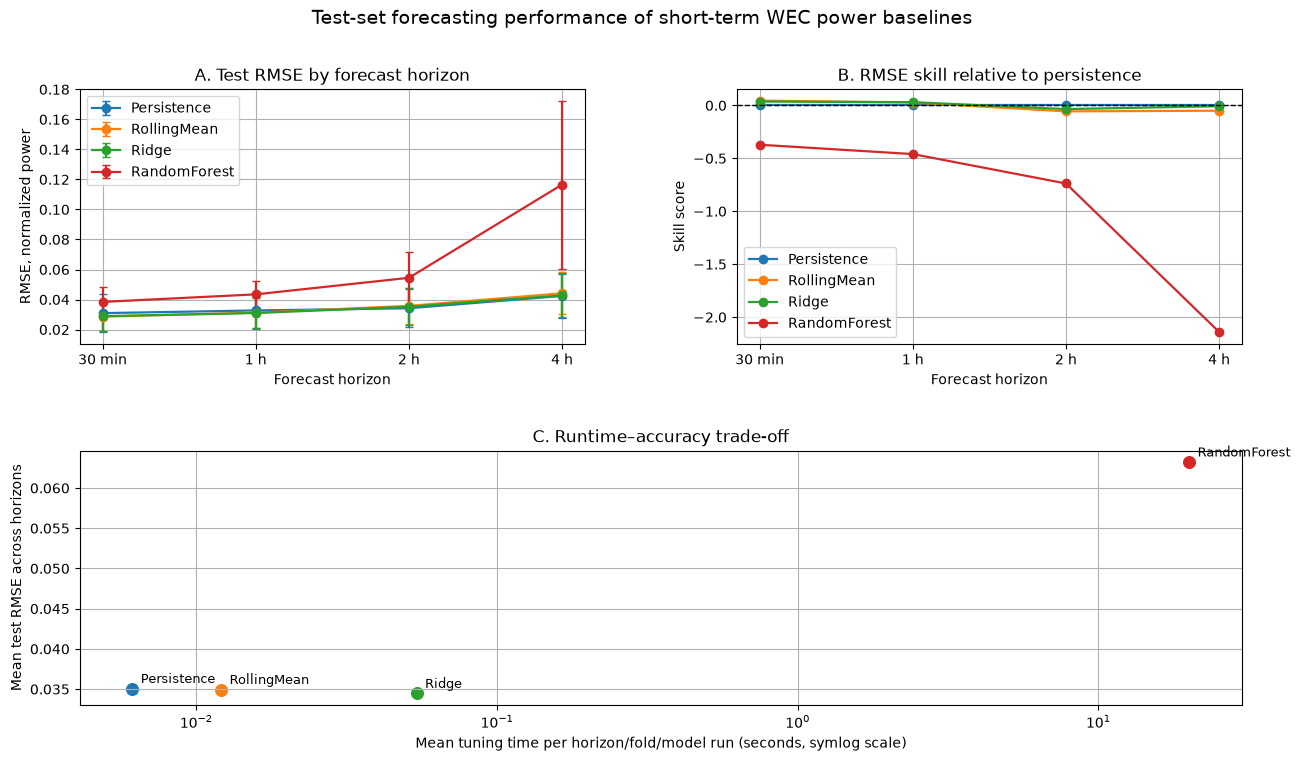

Saved fold-level test metrics to: ../outputs/tables/notebook_03/forecast_metrics_by_fold.csv
Saved summary test metrics to: ../outputs/tables/notebook_03/forecast_metrics_summary.csv
Saved test performance figure to: ../outputs/figures/notebook_03/test_forecasting_performance.png


In [19]:
tables_dir = Path("../outputs/tables/notebook_03")
tables_dir.mkdir(parents=True, exist_ok=True)

figures_dir = Path("../outputs/figures/notebook_03")
figures_dir.mkdir(parents=True, exist_ok=True)

metrics_by_fold_path = tables_dir / "forecast_metrics_by_fold.csv"
metrics_summary_path = tables_dir / "forecast_metrics_summary.csv"
performance_figure_path = figures_dir / "test_forecasting_performance.png"

# Load predictions and runtime table if needed
if "forecast_predictions_df" not in globals():
    forecast_predictions_df = pd.read_parquet(predictions_path)

if "model_runtime_df" not in globals():
    model_runtime_df = pd.read_csv(tables_dir / "model_runtime.csv")


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


# Use only final test blocks
test_predictions_df = forecast_predictions_df.loc[
    forecast_predictions_df["split"] == "test"
].copy()

metric_records = []

for group_cols, group_df in test_predictions_df.groupby(
    ["horizon_steps", "horizon_label", "fold_id", "model"]
):
    horizon_steps, horizon_label, fold_id, model_name = group_cols

    y_true_norm = group_df["y_true_norm"]
    y_pred_norm = group_df["y_pred_norm"]

    y_true_kw = group_df["y_true_kw_250"]
    y_pred_kw = group_df["y_pred_kw_250"]

    error_norm = y_true_norm - y_pred_norm
    error_kw = y_true_kw - y_pred_kw

    metric_records.append(
        {
            "horizon_steps": horizon_steps,
            "horizon_label": horizon_label,
            "fold_id": fold_id,
            "model": model_name,
            "n_test_rows": len(group_df),
            "mae_norm": mean_absolute_error(y_true_norm, y_pred_norm),
            "rmse_norm": rmse(y_true_norm, y_pred_norm),
            "bias_norm": error_norm.mean(),
            "mae_kw_250": mean_absolute_error(y_true_kw, y_pred_kw),
            "rmse_kw_250": rmse(y_true_kw, y_pred_kw),
            "bias_kw_250": error_kw.mean(),
        }
    )

forecast_metrics_by_fold = pd.DataFrame(metric_records)


# Skill scores relative to persistence within the same horizon and fold
persistence_metrics = (
    forecast_metrics_by_fold
    .loc[forecast_metrics_by_fold["model"] == "Persistence"]
    [
        [
            "horizon_steps",
            "fold_id",
            "mae_norm",
            "rmse_norm",
            "mae_kw_250",
            "rmse_kw_250",
        ]
    ]
    .rename(
        columns={
            "mae_norm": "persistence_mae_norm",
            "rmse_norm": "persistence_rmse_norm",
            "mae_kw_250": "persistence_mae_kw_250",
            "rmse_kw_250": "persistence_rmse_kw_250",
        }
    )
)

forecast_metrics_by_fold = forecast_metrics_by_fold.merge(
    persistence_metrics,
    on=["horizon_steps", "fold_id"],
    how="left",
)

forecast_metrics_by_fold["mae_skill_vs_persistence"] = (
    1 - forecast_metrics_by_fold["mae_norm"] / forecast_metrics_by_fold["persistence_mae_norm"]
)

forecast_metrics_by_fold["rmse_skill_vs_persistence"] = (
    1 - forecast_metrics_by_fold["rmse_norm"] / forecast_metrics_by_fold["persistence_rmse_norm"]
)


# Summary across rolling-origin folds
forecast_metrics_summary = (
    forecast_metrics_by_fold
    .groupby(["horizon_steps", "horizon_label", "model"])
    .agg(
        n_folds=("fold_id", "nunique"),
        mean_mae_norm=("mae_norm", "mean"),
        std_mae_norm=("mae_norm", "std"),
        mean_rmse_norm=("rmse_norm", "mean"),
        std_rmse_norm=("rmse_norm", "std"),
        mean_bias_norm=("bias_norm", "mean"),
        mean_mae_kw_250=("mae_kw_250", "mean"),
        std_mae_kw_250=("mae_kw_250", "std"),
        mean_rmse_kw_250=("rmse_kw_250", "mean"),
        std_rmse_kw_250=("rmse_kw_250", "std"),
        mean_bias_kw_250=("bias_kw_250", "mean"),
        mean_mae_skill_vs_persistence=("mae_skill_vs_persistence", "mean"),
        std_mae_skill_vs_persistence=("mae_skill_vs_persistence", "std"),
        mean_rmse_skill_vs_persistence=("rmse_skill_vs_persistence", "mean"),
        std_rmse_skill_vs_persistence=("rmse_skill_vs_persistence", "std"),
    )
    .reset_index()
    .sort_values(["horizon_steps", "mean_rmse_norm", "mean_mae_norm"])
)


# Save human-readable result tables
forecast_metrics_by_fold.to_csv(metrics_by_fold_path, index=False)
forecast_metrics_summary.to_csv(metrics_summary_path, index=False)


# Runtime summary for the performance figure
runtime_for_plot = (
    model_runtime_df
    .groupby("model")
    .agg(
        mean_tuning_time_seconds=("tuning_time_seconds", "mean"),
        mean_final_fit_time_seconds=("final_fit_time_seconds", "mean"),
        mean_test_predict_time_seconds=("test_predict_time_seconds", "mean"),
    )
    .reset_index()
)

accuracy_for_plot = (
    forecast_metrics_summary
    .groupby("model")
    .agg(
        mean_rmse_norm=("mean_rmse_norm", "mean"),
    )
    .reset_index()
)

runtime_accuracy = accuracy_for_plot.merge(
    runtime_for_plot,
    on="model",
    how="left",
)


# Main performance figure
horizon_order = (
    forecast_metrics_summary
    [["horizon_steps", "horizon_label"]]
    .drop_duplicates()
    .sort_values("horizon_steps")
)

horizon_labels = horizon_order["horizon_label"].tolist()

model_order = ["Persistence", "RollingMean", "Ridge", "RandomForest"]

model_colors = {
    "Persistence": "C0",
    "RollingMean": "C1",
    "Ridge": "C2",
    "RandomForest": "C3",
}

fig = plt.figure(figsize=(15, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], hspace=0.42, wspace=0.30)

ax_rmse = fig.add_subplot(gs[0, 0])
ax_skill = fig.add_subplot(gs[0, 1])
ax_tradeoff = fig.add_subplot(gs[1, :])


for model_name in model_order:
    model_df = (
        forecast_metrics_summary
        .loc[forecast_metrics_summary["model"] == model_name]
        .sort_values("horizon_steps")
    )

    if model_df.empty:
        continue

    ax_rmse.errorbar(
        model_df["horizon_label"],
        model_df["mean_rmse_norm"],
        yerr=model_df["std_rmse_norm"],
        marker="o",
        capsize=3,
        linewidth=1.6,
        color=model_colors[model_name],
        label=model_name,
    )

ax_rmse.set_title("A. Test RMSE by forecast horizon")
ax_rmse.set_xlabel("Forecast horizon")
ax_rmse.set_ylabel("RMSE, normalized power")
ax_rmse.legend(frameon=True)


for model_name in model_order:
    model_df = (
        forecast_metrics_summary
        .loc[forecast_metrics_summary["model"] == model_name]
        .sort_values("horizon_steps")
    )

    if model_df.empty:
        continue

    ax_skill.plot(
        model_df["horizon_label"],
        model_df["mean_rmse_skill_vs_persistence"],
        marker="o",
        linewidth=1.6,
        color=model_colors[model_name],
        label=model_name,
    )

ax_skill.axhline(0, color="black", linewidth=1, linestyle="--")
ax_skill.set_title("B. RMSE skill relative to persistence")
ax_skill.set_xlabel("Forecast horizon")
ax_skill.set_ylabel("Skill score")
ax_skill.legend(frameon=True)


for model_name in model_order:
    model_df = runtime_accuracy.loc[
        runtime_accuracy["model"] == model_name
    ]

    if model_df.empty:
        continue

    row = model_df.iloc[0]

    ax_tradeoff.scatter(
        row["mean_tuning_time_seconds"],
        row["mean_rmse_norm"],
        s=70,
        color=model_colors[model_name],
    )

    ax_tradeoff.annotate(
        model_name,
        (
            row["mean_tuning_time_seconds"],
            row["mean_rmse_norm"],
        ),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=9,
    )

ax_tradeoff.set_xscale("symlog", linthresh=0.01)
ax_tradeoff.set_title("C. Runtime–accuracy trade-off")
ax_tradeoff.set_xlabel("Mean tuning time per horizon/fold/model run (seconds, symlog scale)")
ax_tradeoff.set_ylabel("Mean test RMSE across horizons")

fig.suptitle(
    "Test-set forecasting performance of short-term WEC power baselines",
    fontsize=14,
    y=0.98,
)

fig.savefig(performance_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved fold-level test metrics to: {metrics_by_fold_path}")
print(f"Saved summary test metrics to: {metrics_summary_path}")
print(f"Saved test performance figure to: {performance_figure_path}")

The test-set results show that the simple autoregressive baselines are strong for this short-term forecasting task. Ridge regression gives the most balanced performance overall, with low RMSE, competitive or positive skill relative to persistence, and low computational cost.

Persistence and the rolling-mean baseline remain competitive, especially at shorter horizons, which is expected for an autocorrelated estimated WEC power series. The random forest model is substantially slower and does not improve test performance in this setup. This suggests that, for the current power-only feature set and limited short-term horizons, model simplicity is preferable to added non-linear complexity.

As expected, forecast error generally increases with horizon, reflecting the increasing difficulty of predicting estimated WEC power further ahead without external wave-forecast inputs.

## Example forecast trajectories

The aggregate test metrics show overall performance, but they do not show how the forecasts behave through time.

This section visualizes example test-set forecast trajectories for the shortest and longest forecast horizons. Forecasts are aligned by `target_time`, so each prediction is compared with the realized estimated WEC power at the time being forecast.

Only the main interpretable models are shown: persistence, rolling mean, and ridge regression. The random forest is omitted from this trajectory plot because the previous performance comparison showed that it is slower and not competitive for this setup.

The plotted windows are selected automatically from the final test fold by choosing periods with relatively high variation in the true target series.

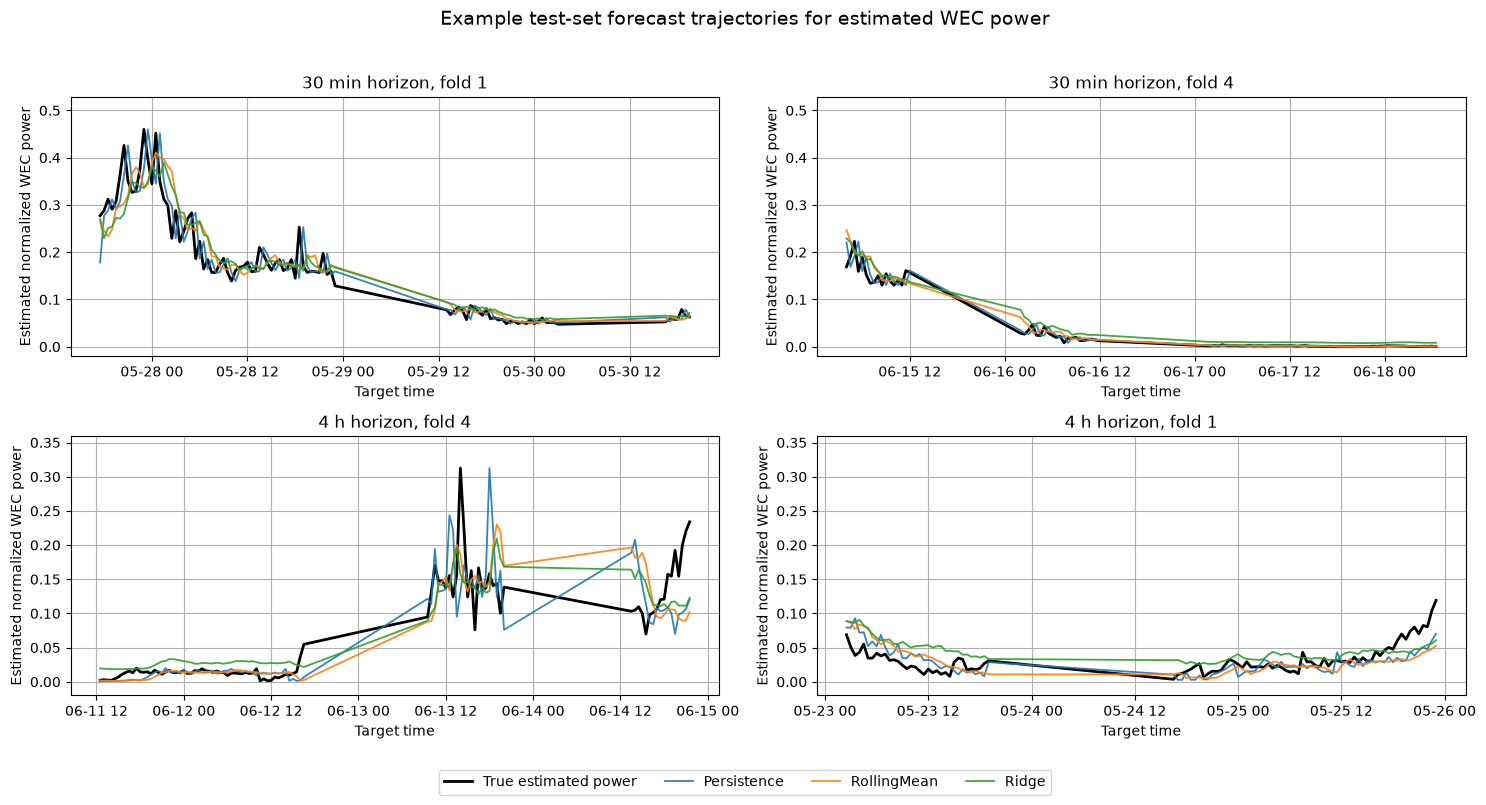

Saved example forecast trajectory figure to: ../outputs/figures/notebook_03/example_forecast_trajectories_2x2.png


In [15]:
# Load predictions if needed
if "forecast_predictions_df" not in globals():
    forecast_predictions_df = pd.read_parquet(predictions_path)

figures_dir = Path("../outputs/figures/notebook_03")
figures_dir.mkdir(parents=True, exist_ok=True)

trajectory_figure_path = figures_dir / "example_forecast_trajectories_2x2.png"

test_predictions_df = forecast_predictions_df.loc[
    forecast_predictions_df["split"] == "test"
].copy()

model_order = ["Persistence", "RollingMean", "Ridge"]

plot_horizons = [min(horizons.keys()), max(horizons.keys())]
n_windows = 2
window_size = 96

rng = np.random.default_rng(random_state)

fig, axes = plt.subplots(
    len(plot_horizons),
    n_windows,
    figsize=(15, 8),
    sharex=False,
    sharey=False,
)

if len(plot_horizons) == 1:
    axes = np.array([axes])

legend_handles = None
legend_labels = None

for row_idx, horizon_steps in enumerate(plot_horizons):
    horizon_label = horizons[horizon_steps]["horizon_label"]

    horizon_plot_df = test_predictions_df.loc[
        (test_predictions_df["horizon_steps"] == horizon_steps)
        & (test_predictions_df["model"].isin(model_order))
    ].copy()

    available_folds = sorted(horizon_plot_df["fold_id"].unique())

    if len(available_folds) == 0:
        for col_idx in range(n_windows):
            axes[row_idx, col_idx].set_title(f"No predictions available: {horizon_label}")
        continue

    n_selected_folds = min(n_windows, len(available_folds))
    selected_folds = rng.choice(
        available_folds,
        size=n_selected_folds,
        replace=False,
    )

    if len(selected_folds) < n_windows:
        selected_folds = list(selected_folds) + [selected_folds[-1]] * (n_windows - len(selected_folds))

    row_windows = []

    for fold_id in selected_folds:
        fold_df = horizon_plot_df.loc[horizon_plot_df["fold_id"] == fold_id].copy()

        base_df = (
            fold_df
            .loc[fold_df["model"] == "Persistence"]
            [["sample_id", "target_time", "y_true_norm"]]
            .drop_duplicates()
            .sort_values("sample_id")
            .reset_index(drop=True)
        )

        if len(base_df) <= window_size:
            base_window = base_df.copy()
        else:
            max_start = len(base_df) - window_size
            start_idx = int(rng.integers(0, max_start + 1))
            base_window = base_df.iloc[start_idx:start_idx + window_size].copy()

        row_windows.append(
            {
                "fold_id": fold_id,
                "window_df": base_window,
            }
        )

    horizon_max = max(
        window_info["window_df"]["y_true_norm"].max()
        for window_info in row_windows
    )
    y_upper = min(1.03, max(0.12, horizon_max * 1.15))

    for col_idx, window_info in enumerate(row_windows):
        ax = axes[row_idx, col_idx]

        fold_id = window_info["fold_id"]
        base_window = window_info["window_df"]
        sample_ids = base_window["sample_id"].to_numpy()

        fold_df = horizon_plot_df.loc[horizon_plot_df["fold_id"] == fold_id].copy()

        ax.plot(
            base_window["target_time"],
            base_window["y_true_norm"],
            color="black",
            linewidth=2.0,
            label="True estimated power",
        )

        for model_name in model_order:
            model_df = fold_df.loc[
                (fold_df["model"] == model_name)
                & (fold_df["sample_id"].isin(sample_ids))
            ].sort_values("sample_id")

            if model_df.empty:
                continue

            ax.plot(
                model_df["target_time"],
                model_df["y_pred_norm"],
                linewidth=1.3,
                alpha=0.9,
                label=model_name,
            )

        ax.set_title(
            f"{horizon_label} horizon, fold {fold_id}"
        )
        ax.set_xlabel("Target time")
        ax.set_ylabel("Estimated normalized WEC power")
        ax.set_ylim(-0.02, y_upper)

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

fig.suptitle(
    "Example test-set forecast trajectories for estimated WEC power",
    fontsize=14,
    y=0.98,
)

if legend_handles is not None:
    fig.legend(
        legend_handles,
        legend_labels,
        loc="lower center",
        ncol=4,
        frameon=True,
        bbox_to_anchor=(0.5, -0.01),
    )

fig.tight_layout(rect=[0, 0.05, 1, 0.96])
fig.savefig(trajectory_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved example forecast trajectory figure to: {trajectory_figure_path}")

The example trajectories show that the selected baselines capture the broad evolution of estimated WEC power reasonably well, especially at the 30 min horizon. Short-term fluctuations and abrupt changes are harder to follow, which is expected for a wave-driven power signal with strong variability.

At the 4 h horizon, forecasts become smoother and show more lag around changing conditions. This is consistent with the aggregate metrics: longer forecast horizons are more difficult without external wave-forecast inputs.

Overall, the trajectories support the main test-set result: simple autoregressive baselines, especially ridge regression and rolling-mean forecasting, provide intuitive and competitive short-term forecasts for the simplified estimated WEC power target.

## Residual diagnostics

The point-forecast metrics show average test performance, but the residuals show how forecast errors are distributed.

This section examines test-set residuals for the main interpretable baselines. Residuals are defined as:

$$
e_t = y_t - \hat{y}_t
$$

Positive residuals mean the model under-predicted the estimated WEC power, while negative residuals mean it over-predicted.

These residuals are especially important for the next notebook, where forecast uncertainty and prediction intervals are evaluated.

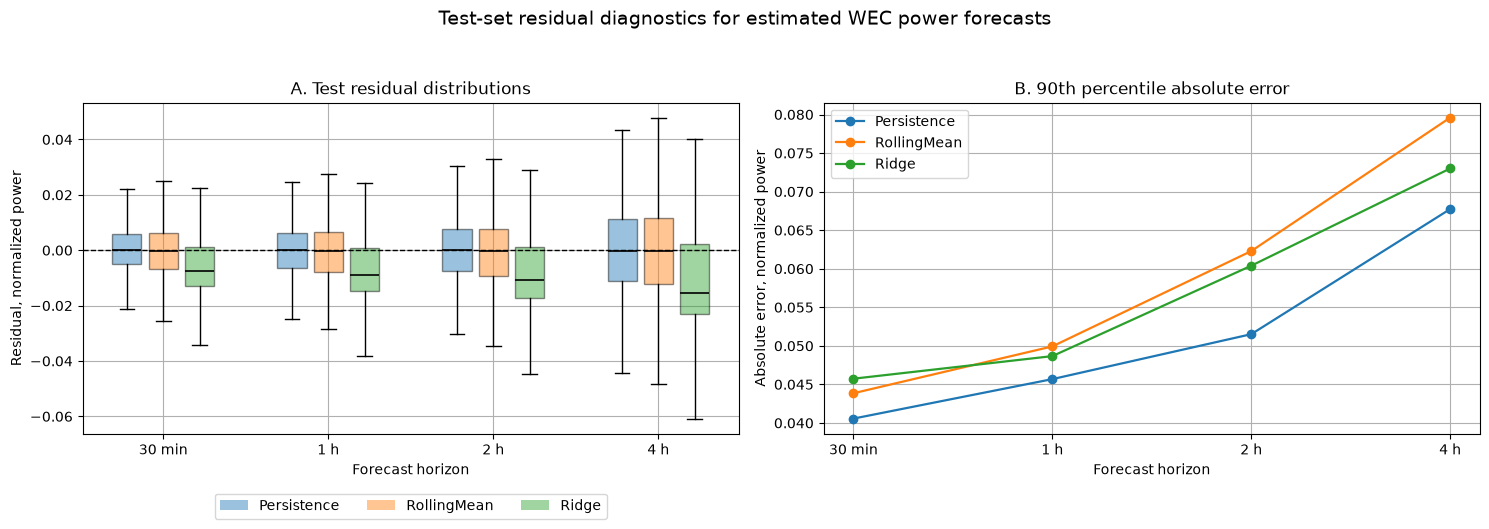

Saved residual diagnostic summary to: ../outputs/tables/notebook_03/residual_diagnostics_summary.csv
Saved residual diagnostic figure to: ../outputs/figures/notebook_03/residual_diagnostics.png


In [17]:
# Load predictions if needed
if "forecast_predictions_df" not in globals():
    forecast_predictions_df = pd.read_parquet(predictions_path)

from matplotlib.patches import Patch

tables_dir = Path("../outputs/tables/notebook_03")
tables_dir.mkdir(parents=True, exist_ok=True)

figures_dir = Path("../outputs/figures/notebook_03")
figures_dir.mkdir(parents=True, exist_ok=True)

residual_summary_path = tables_dir / "residual_diagnostics_summary.csv"
residual_figure_path = figures_dir / "residual_diagnostics.png"

diagnostic_models = ["Persistence", "RollingMean", "Ridge"]

test_residuals_df = forecast_predictions_df.loc[
    (forecast_predictions_df["split"] == "test")
    & (forecast_predictions_df["model"].isin(diagnostic_models))
].copy()

test_residuals_df["abs_error_norm"] = test_residuals_df["error_norm"].abs()
test_residuals_df["abs_error_kw_250"] = test_residuals_df["error_kw_250"].abs()


# Residual summary table
residual_summary = (
    test_residuals_df
    .groupby(["horizon_steps", "horizon_label", "model"])
    .agg(
        n_test_rows=("error_norm", "size"),
        mean_error_norm=("error_norm", "mean"),
        median_error_norm=("error_norm", "median"),
        std_error_norm=("error_norm", "std"),
        q05_error_norm=("error_norm", lambda x: x.quantile(0.05)),
        q95_error_norm=("error_norm", lambda x: x.quantile(0.95)),
        median_abs_error_norm=("abs_error_norm", "median"),
        q90_abs_error_norm=("abs_error_norm", lambda x: x.quantile(0.90)),
        mean_error_kw_250=("error_kw_250", "mean"),
        std_error_kw_250=("error_kw_250", "std"),
        q90_abs_error_kw_250=("abs_error_kw_250", lambda x: x.quantile(0.90)),
    )
    .reset_index()
    .sort_values(["horizon_steps", "model"])
)

residual_summary.to_csv(residual_summary_path, index=False)


# Figure data
horizon_order = (
    test_residuals_df[["horizon_steps", "horizon_label"]]
    .drop_duplicates()
    .sort_values("horizon_steps")
)

horizon_labels = horizon_order["horizon_label"].tolist()
x_positions = np.arange(len(horizon_labels))

box_width = 0.22
model_offsets = {
    "Persistence": -box_width,
    "RollingMean": 0.0,
    "Ridge": box_width,
}

model_colors = {
    "Persistence": "C0",
    "RollingMean": "C1",
    "Ridge": "C2",
}


fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5.5),
    sharex=False,
)

ax_resid, ax_abs = axes


# A. Signed residual distributions
for model_name in diagnostic_models:
    values_by_horizon = []
    positions = []

    for i, horizon_steps in enumerate(horizon_order["horizon_steps"]):
        values = test_residuals_df.loc[
            (test_residuals_df["horizon_steps"] == horizon_steps)
            & (test_residuals_df["model"] == model_name),
            "error_norm",
        ].dropna()

        values_by_horizon.append(values)
        positions.append(i + model_offsets[model_name])

    box = ax_resid.boxplot(
        values_by_horizon,
        positions=positions,
        widths=box_width * 0.8,
        patch_artist=True,
        showfliers=False,
        manage_ticks=False,
    )

    for patch in box["boxes"]:
        patch.set_facecolor(model_colors[model_name])
        patch.set_alpha(0.45)

    for median in box["medians"]:
        median.set_color("black")
        median.set_linewidth(1.2)

ax_resid.axhline(0, color="black", linewidth=1, linestyle="--")
ax_resid.set_title("A. Test residual distributions")
ax_resid.set_xlabel("Forecast horizon")
ax_resid.set_ylabel("Residual, normalized power")
ax_resid.set_xticks(x_positions)
ax_resid.set_xticklabels(horizon_labels)

box_legend_handles = [
    Patch(
        facecolor=model_colors[model_name],
        alpha=0.45,
        label=model_name,
    )
    for model_name in diagnostic_models
]

ax_resid.legend(
    handles=box_legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=len(diagnostic_models),
    frameon=True,
)


# B. 90th percentile absolute error by horizon
for model_name in diagnostic_models:
    model_summary = (
        residual_summary
        .loc[residual_summary["model"] == model_name]
        .sort_values("horizon_steps")
    )

    ax_abs.plot(
        model_summary["horizon_label"],
        model_summary["q90_abs_error_norm"],
        marker="o",
        linewidth=1.6,
        label=model_name,
    )

ax_abs.set_title("B. 90th percentile absolute error")
ax_abs.set_xlabel("Forecast horizon")
ax_abs.set_ylabel("Absolute error, normalized power")
ax_abs.legend(frameon=True)


fig.suptitle(
    "Test-set residual diagnostics for estimated WEC power forecasts",
    fontsize=14,
    y=0.98,
)

fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(residual_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved residual diagnostic summary to: {residual_summary_path}")
print(f"Saved residual diagnostic figure to: {residual_figure_path}")

The residual diagnostics show that test residuals are generally centered close to zero, indicating no large systematic bias for the main baselines. However, the residual spread increases with forecast horizon, which is consistent with the increasing difficulty of longer-ahead WEC power forecasting.

Persistence has the lowest 90th percentile absolute error in this diagnostic view, especially at longer horizons. Ridge remains a competitive low-cost ML baseline, but its residuals show a slightly stronger tendency toward negative errors at longer horizons, meaning it sometimes over-predicts the estimated WEC power.

These results reinforce the importance of evaluating both average metrics and residual behavior. For the next uncertainty notebook, the residual spread and horizon-dependent error growth provide a direct motivation for calibrated prediction intervals rather than relying only on point forecasts.

## Summary

This notebook built short-term point-forecasting baselines for the estimated WEC power time series prepared in the previous notebooks.

The forecasting task used the normalized estimated WEC power target as the main modelling and visualization scale. Corresponding 250 kW-scale true values, predictions, and errors were also computed and saved for downstream physical interpretation. Missing target values were not imputed. Lag, rolling, and future-target features were created only within continuous valid segments, preventing artificial continuity across data gaps.

A compact power-only autoregressive feature set was used for all horizons. Sea-state variables such as wave height, wave period, and wave-power flux were intentionally excluded from the main benchmark because the estimated WEC power target was itself derived from sea-state assumptions.

The evaluation used chronological rolling-origin folds with separate training, calibration/validation, and test blocks. Hyperparameters were selected on the calibration block, while final performance was evaluated only on the test block.

The main findings were:

* Forecast error increased with horizon, as expected for longer-ahead WEC power forecasting without external wave-forecast inputs.
* Persistence and rolling-mean baselines were strong, especially at short horizons, reflecting the autocorrelation of the estimated WEC power series.
* Ridge regression provided the most balanced ML baseline, combining competitive test performance with low computational cost.
* Random forest regression was substantially slower and did not improve test performance in this compact power-only setup.
* Residual diagnostics showed increasing error spread with horizon, motivating calibrated prediction intervals in the next notebook.

The saved prediction and residual outputs from this notebook provide the point-forecast basis for the following uncertainty-analysis notebook.
